# PCB Binary Classifier - MobileNetV2
Uses transfer learning with MobileNetV2 (alpha=0.35) for PCB / not-PCB detection.


## 1. Imports

In [1]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers
from tensorflow import data as tf_data
from tensorflow import lite

print("TF version:", tf.__version__)
print("Keras version:", keras.__version__)

2026-03-01 15:39:37.864962: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772379578.055339      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772379578.113825      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772379578.556318      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772379578.556360      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772379578.556362      55 computation_placer.cc:177] computation placer alr

TF version: 2.19.0
Keras version: 3.10.0


## 2. Config

In [2]:
INPUT_SIZE  = 96        # MobileNetV2 minimum is 96x96
BATCH_SIZE  = 32
EPOCHS_TOP  = 10       # train classifier head only
EPOCHS_FINE = 10       # fine-tune top layers of MobileNetV2
CLASS_NUM   = 2
LABELS      = ["not_pcb", "pcb"] 

TRAIN_DIR    = "/kaggle/working/balanced/train"
VALIDATE_DIR = "/kaggle/working/balanced/validate"
TEST_DIR     = "/kaggle/working/balanced/test"

## 3. Rebalance Dataset

In [3]:
val_not_pcb = "/kaggle/input/datasets/hassenalrubei/pcbvnotpcb/dataset/validate/not_pcb"
files = os.listdir(val_not_pcb)
random.seed(42)
keep = set(random.sample(files, 51))  # match PCB count

for split in ["train", "validate", "test"]:
    for cls in ["pcb", "not_pcb"]:
        src = f"/kaggle/input/datasets/hassenalrubei/pcbvnotpcb/dataset/{split}/{cls}"
        dst = f"/kaggle/working/balanced/{split}/{cls}"
        os.makedirs(dst, exist_ok=True)
        for f in os.listdir(src):
            if split == "validate" and cls == "not_pcb" and f not in keep:
                continue
            shutil.copy(os.path.join(src, f), dst)

for split in ["train", "validate", "test"]:
    path = f"/kaggle/working/balanced/{split}"
    counts = {c: len(os.listdir(os.path.join(path, c))) for c in os.listdir(path)}
    print(f"{split}: {counts}")

train: {'pcb': 847, 'not_pcb': 1116}
validate: {'pcb': 51, 'not_pcb': 51}
test: {'pcb': 102, 'not_pcb': 240}


## 4. Data Augmentation & Loading

Normalisation uses `img / 127.5 - 1` to map pixels to `[-1, 1]`, which is what MobileNetV2 expects.

In [4]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

def load_ds(path, augment=False, shuffle=False):
    ds = keras.utils.image_dataset_from_directory(
        path,
        validation_split=None,
        seed=1337,
        shuffle=shuffle,
        image_size=(INPUT_SIZE, INPUT_SIZE),
        batch_size=BATCH_SIZE,
        label_mode="categorical",
        class_names=LABELS,
    )
    if augment:
        ds = ds.map(
            lambda img, label: (data_augmentation(img) / 127.5 - 1, label),
            num_parallel_calls=tf_data.AUTOTUNE,
        )
    else:
        ds = ds.map(
            lambda img, label: (img / 127.5 - 1, label),
            num_parallel_calls=tf_data.AUTOTUNE,
        )
    return ds.prefetch(tf_data.AUTOTUNE)

train_ds    = load_ds(TRAIN_DIR,    augment=True,  shuffle=True)
validate_ds = load_ds(VALIDATE_DIR, augment=False, shuffle=False)
test_ds     = load_ds(TEST_DIR,     augment=False, shuffle=False)

print("Classes:", LABELS)

Found 1963 files belonging to 2 classes.


I0000 00:00:1772379629.497118      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 102 files belonging to 2 classes.
Found 342 files belonging to 2 classes.
Classes: ['not_pcb', 'pcb']


## 5. Build Model



In [5]:
def build_model():
    input_shape = (INPUT_SIZE, INPUT_SIZE, 3)
    inputs = layers.Input(shape=input_shape)

    base = keras.applications.MobileNetV2(
        alpha=0.35,
        include_top=False,
        input_shape=input_shape,
        input_tensor=inputs,
        weights="imagenet",
    )
    base.trainable = False  # freeze pretrained weights initially

    x = layers.GlobalAveragePooling2D(name="avg_pool")(base.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(CLASS_NUM, activation="softmax")(x)

    return keras.Model(inputs, outputs)

model = build_model()
model.summary()

2019640/2019640 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        432 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │         64 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        144 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48, 8) │        128 │ expanded_conv_de… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48, 8) │         32 │ expanded_conv_pr… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │        384 │ expanded_conv_pr… │
│ (Conv2D)            │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        192 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        432 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        192 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24, 8) │        384 │ block_1_depthwis

 Total params: 417,890 (1.59 MB)

 Trainable params: 5,122 (20.01 KB)

 Non-trainable params: 412,768 (1.57 MB)

## 6. Phase 1 — Train Classifier Head

In [15]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1),
]

history_top = model.fit(
    train_ds,
    validation_data=validate_ds,
    epochs=EPOCHS_TOP,
    callbacks=callbacks,
)

Epoch 1/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 20s 188ms/step - accuracy: 0.9587 - loss: 0.1298 - val_accuracy: 0.9118 - val_loss: 0.1589 - learning_rate: 0.0010
Epoch 2/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9530 - loss: 0.1239 - val_accuracy: 0.9216 - val_loss: 0.1342 - learning_rate: 0.0010
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9562 - loss: 0.1142 - val_accuracy: 0.9216 - val_loss: 0.1578 - learning_rate: 0.0010
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9458 - loss: 0.1384 - val_accuracy: 0.9314 - val_loss: 0.1482 - learning_rate: 0.0010
Epoch 5/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9628 - loss: 0.0973 - val_accuracy: 0.9510 - val_loss: 0.1070 - learning_rate: 0.0010
Epoch 6/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9489 - loss: 0.1249 - val_accuracy: 0.9412 - val_loss: 0.1121 - learning_rate: 0.0010
Epoch 7/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9601 - loss: 0.1022 - val_a

## 8. Evaluate on Test Set

In [7]:
loss, acc = model.evaluate(test_ds)
print(f"Test accuracy: {acc:.2%}  |  Test loss: {loss:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 407ms/step - accuracy: 0.9765 - loss: 0.0737
Test accuracy: 93.27%  |  Test loss: 0.1757


## 9. Training History

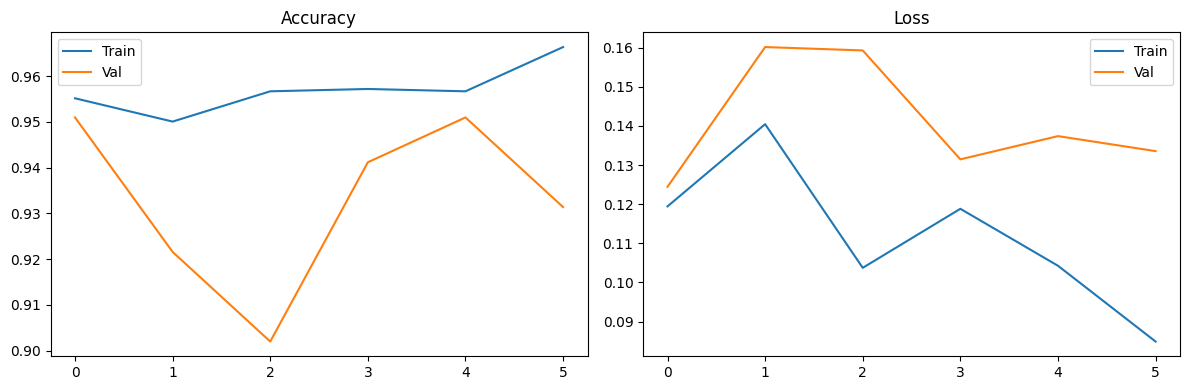

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_top.history["accuracy"],     label="Train")
axes[0].plot(history_top.history["val_accuracy"], label="Val")
axes[0].set_title("Accuracy")
axes[0].legend()

axes[1].plot(history_top.history["loss"],     label="Train")
axes[1].plot(history_top.history["val_loss"], label="Val")
axes[1].set_title("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

# Evaluate Metrics

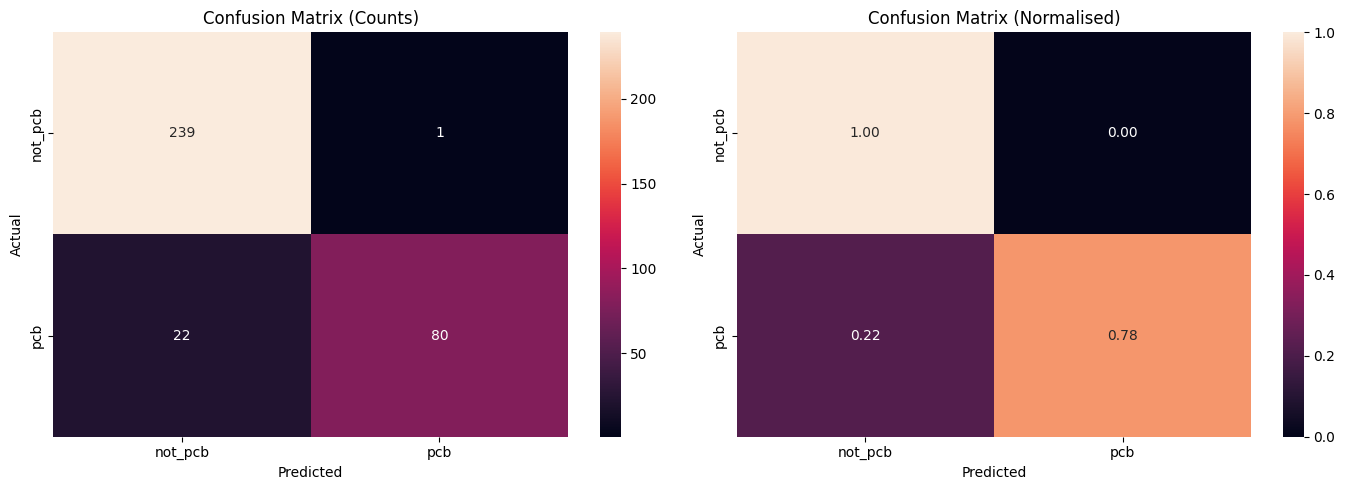

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = confusion_matrix(y_true, y_pred)

# Normalize by row 
cm_normalised = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw 
sns.heatmap(cm, annot=True, fmt='d',
    xticklabels=['not_pcb', 'pcb'],
    yticklabels=['not_pcb', 'pcb'],
    ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Normalised proportions
sns.heatmap(cm_normalised, annot=True, fmt='.2f',
    xticklabels=['not_pcb', 'pcb'],
    yticklabels=['not_pcb', 'pcb'],
    vmin=0, vmax=1,
    ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalised)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrix_both.png', dpi=150)
plt.show()

## 10. Convert to INT8 TFLite



In [10]:
def representative_dataset():
    for images, _ in train_ds.take(100):
        for img in images:
            # Images are already normalised to [-1, 1]; yield as float32
            yield [tf.expand_dims(img, 0)]

converter = lite.TFLiteConverter.from_keras_model(model)
converter._experimental_disable_per_channel_quantization_for_dense_layers = True
converter.optimizations = [lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

with open("trained.tflite", "wb") as f:
    f.write(tflite_model)

print(f"TFLite model size: {len(tflite_model) / 1024:.1f} KB")

INFO:tensorflow:Assets written to: /tmp/tmpbvf9c56y/assets


INFO:tensorflow:Assets written to: /tmp/tmpbvf9c56y/assets


Saved artifact at '/tmp/tmpbvf9c56y'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  134338940525584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134338940526736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134338940527696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134338940527312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134338940527504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134338940526544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134338940529232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134338940529424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134338940528656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134338940528080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134338940526928:

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1772279723.448376      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1772279723.448405      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1772279723.592514      55 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


TFLite model size: 603.5 KB


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


## 11. Verify Model Loads (Sanity Check)

In [11]:
import tensorflow as tf

interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input:",  input_details[0]["shape"],  "dtype:", input_details[0]["dtype"])
print("Output:", output_details[0]["shape"], "dtype:", output_details[0]["dtype"])

# Tensor arena estimate
details = interpreter.get_tensor_details()
total = sum(
    abs(np.prod(t["shape"])) * np.dtype(t["dtype"]).itemsize
    for t in details
)
print(f"Estimated tensor arena: {total / 1024:.1f} KB")
print(f"File size: {os.path.getsize('trained.tflite') / 1024:.1f} KB")
print("allocate_tensors() passed — model should load on OpenMV")

Input: [ 1 96 96  3] dtype: <class 'numpy.int8'>
Output: [1 2] dtype: <class 'numpy.int8'>
Estimated tensor arena: 959.6 KB
File size: 603.5 KB
allocate_tensors() passed — model should load on OpenMV


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## 12. Generate labels.txt

Required alongside `trained.tflite` on the OpenMV drive.

In [12]:
with open("labels.txt", "w") as f:
    f.write("\n".join(LABELS))

print("labels.txt contents:")
print(open("labels.txt").read())

labels.txt contents:
not_pcb
pcb


## 13. Download Files



In [12]:
print("Files ready to download:")
for fname in ["trained.tflite", "labels.txt"]:
    size = os.path.getsize(fname)
    print(f"  {fname}: {size / 1024:.1f} KB")


Files ready to download:
  trained.tflite: 603.5 KB
  labels.txt: 0.0 KB
